In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from sklearn.preprocessing import MinMaxScaler

plt.style.use("default")

pd.set_option("display.max_columns",None)

In [2]:
nav_df = pd.read_csv("../data/processed/clean_nav.csv")

performance_df = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

Task 1: Daily Returns


In [5]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

nav_df["daily_return"] = (

    nav_df.groupby("amfi_code")["nav"]

    .pct_change()

)
nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


Return Distribution

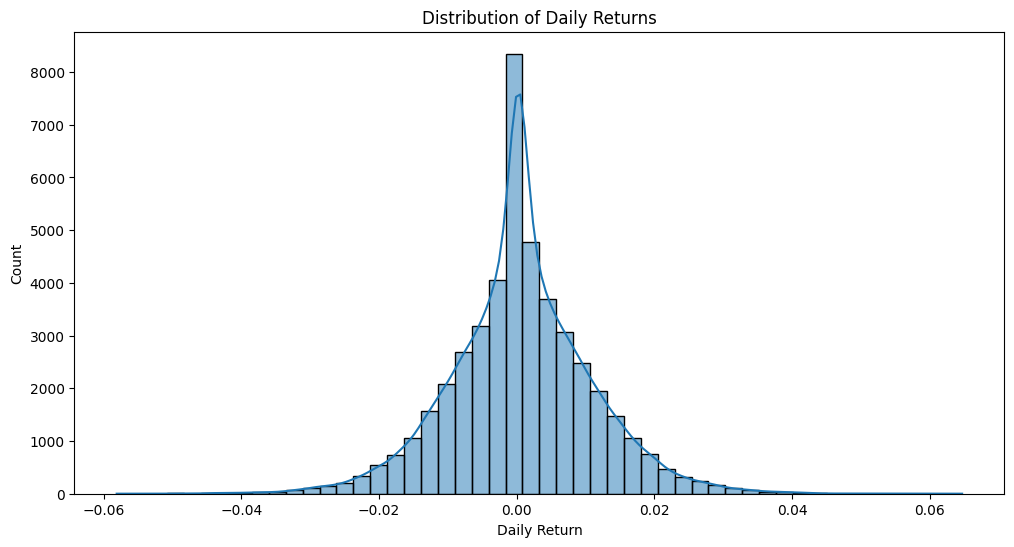

In [6]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Daily Returns"
)

plt.xlabel("Daily Return")

plt.show()

The daily return distribution is centered near zero and exhibits a bell-shaped pattern, indicating normal market fluctuations. Extreme gains and losses occur less frequently than moderate return movements.

CAGR Analysis

In [7]:
def calculate_cagr(
        start_nav,
        end_nav,
        years
):

    return (

        (end_nav/start_nav)

        **(1/years)

        -1

    )*100

In [8]:
cagr_results=[]
for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ].sort_values("date")

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    cagr_5y = calculate_cagr(
        start_nav,
        end_nav,
        5
    )

    cagr_results.append(
        [fund,cagr_5y]
    )
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_5y"
    ]
)

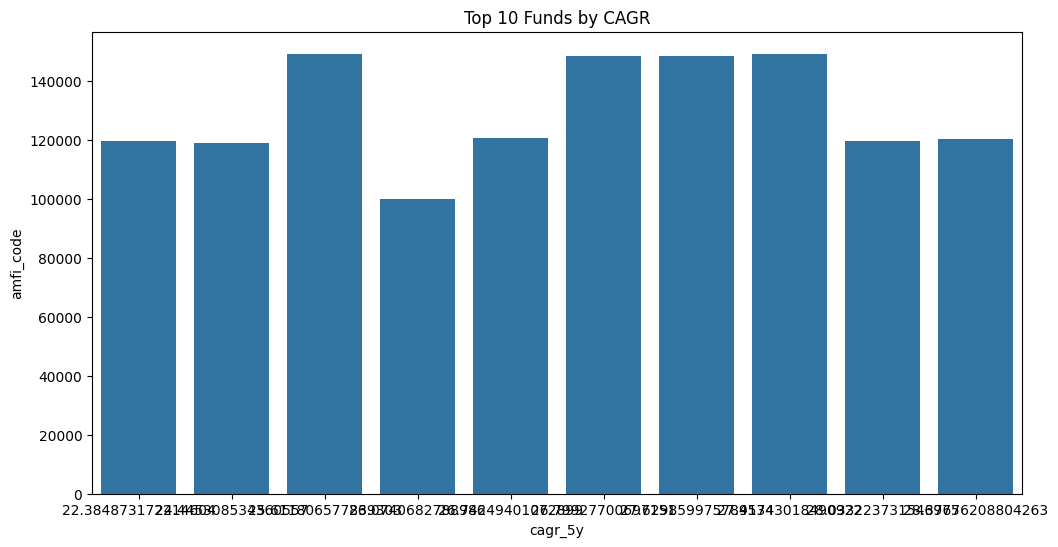

In [9]:
top10 = cagr_df.sort_values(
    "cagr_5y",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="cagr_5y",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by CAGR"
)

plt.show()

Sharpe Ratio

In [10]:
RF = 0.065
sharpe_list=[]
for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    annual_return = (

        returns.mean()

        *252

    )

    volatility = (

        returns.std()

        *np.sqrt(252)

    )

    sharpe = (

        annual_return-RF

    ) / volatility

    sharpe_list.append(
        [fund,sharpe]
    )
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

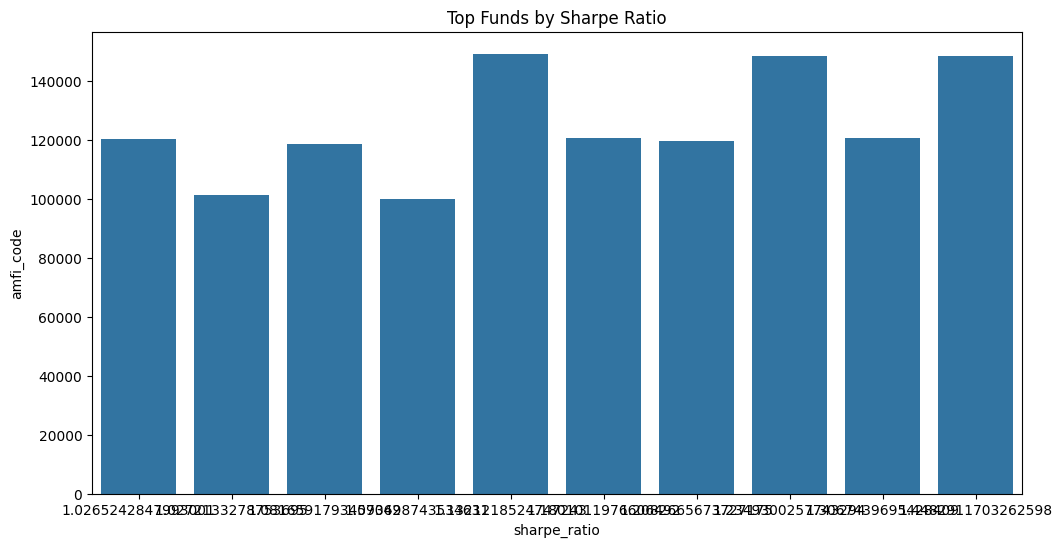

In [11]:
top_sharpe = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="amfi_code"
)

plt.title(
    "Top Funds by Sharpe Ratio"
)

plt.show()

Sortino Ratio

In [12]:
sortino_results=[]
for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    downside = returns[
        returns<0
    ]

    downside_std = (
        downside.std()
        *np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        *252
    )

    sortino = (

        annual_return-RF

    ) / downside_std

    sortino_results.append(
        [fund,sortino]
    )

Alpha & Beta

In [13]:
nifty100 = benchmark_df[
    benchmark_df["index_name"]
    == "NIFTY100"
].copy()
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

Regression

In [14]:
alpha_beta=[]
for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ][["date","daily_return"]]

    merged = pd.merge(
        temp,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    slope, intercept, r, p, std = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha = intercept * 252 * 100

    beta = slope

    alpha_beta.append(
        [fund,alpha,beta]
    )
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

Maximum Drawdown

In [15]:
dd_results=[]
for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ]

    returns = temp[
        "daily_return"
    ].fillna(0)

    cumulative = (

        1+returns

    ).cumprod()

    running_max = (
        cumulative.cummax()
    )

    drawdown = (

        cumulative

        / running_max

        -1

    )

    max_dd = drawdown.min()

    dd_results.append(
        [fund,max_dd]
    )

Fund Scorecard

In [18]:
score_df = performance_df.copy()
score_df["return_rank"] = score_df[
    "return_3yr_pct"
].rank(
    ascending=False
)

score_df["sharpe_rank"] = score_df[
    "sharpe_ratio"
].rank(
    ascending=False
)

score_df["alpha_rank"] = score_df[
    "alpha"
].rank(
    ascending=False
)

score_df["expense_rank"] = score_df[
    "expense_ratio_pct"
].rank(
    ascending=True
)

score_df["dd_rank"] = score_df[
    "max_drawdown_pct"
].rank(
    ascending=True
)
score_df["score"]=(

0.30*score_df["return_rank"]

+0.25*score_df["sharpe_rank"]

+0.20*score_df["alpha_rank"]

+0.15*score_df["expense_rank"]

+0.10*score_df["dd_rank"]

)
scaler = MinMaxScaler(
    feature_range=(0,100)
)

score_df["fund_score"] = (
    100 -
    scaler.fit_transform(
        score_df[["score"]]
    )
)
score_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

Benchmark Comparison

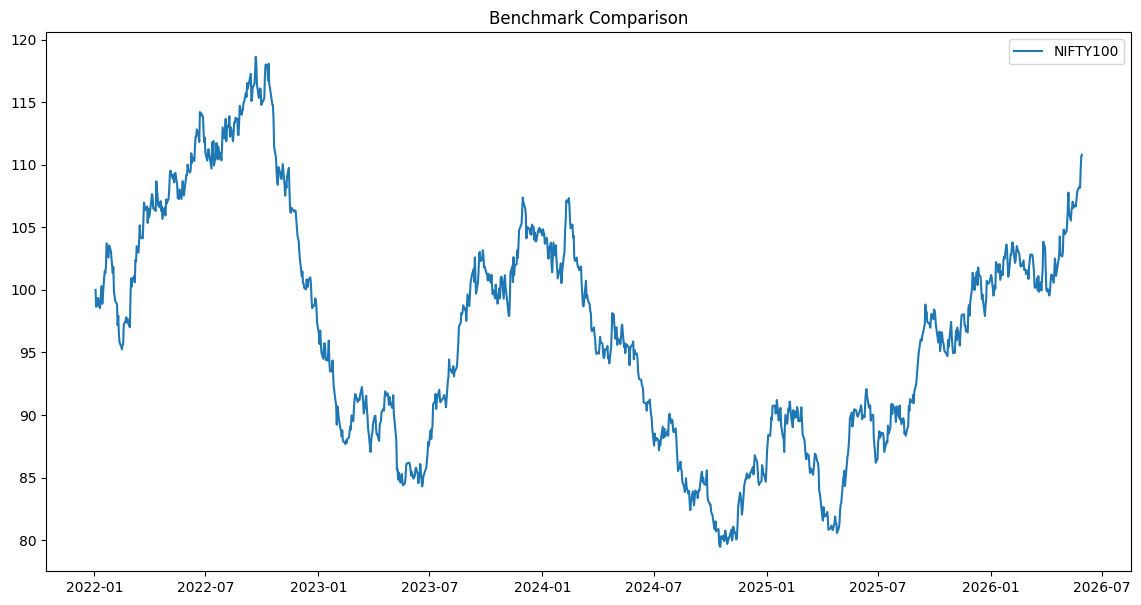

<Figure size 640x480 with 0 Axes>

In [19]:
top5 = score_df.sort_values(
    "fund_score",
    ascending=False
).head(5)
plt.figure(figsize=(14,7))

plt.plot(
    nifty100["date"],
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    *100,
    label="NIFTY100"
)

plt.legend()

plt.title(
    "Benchmark Comparison"
)

plt.show()
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)